# Risk Index

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

In [15]:
# covid data
df_covid = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [16]:
df_covid = df_covid[df_covid['country'] == 'Colombia'].copy()
df_covid_s = df_covid[['date', 'cases', 'new_cases', 'StringencyIndex_Average', 'pop_vaccinated']].copy()
df_covid_s.rename(columns={'StringencyIndex_Average': 'stringency', 'cases':'covid_cum', 'new_cases':'covid'}, inplace=True)

In [17]:
# epidemics
df_epidemics = pd.read_csv('../Data/gold/epidemics.csv')
df_epidemics.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [18]:
df_epidemics.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mob_index', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

# Merge

In [19]:
df_final = df_epidemics.merge(df_covid_s, how='left', left_on='date', right_on='date')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   week              197 non-null    object 
 1   dengue            197 non-null    int64  
 2   zika              197 non-null    float64
 3   chik              197 non-null    float64
 4   var               197 non-null    float64
 5   date              197 non-null    object 
 6   tavg              197 non-null    float64
 7   tmin              197 non-null    float64
 8   tmax              197 non-null    float64
 9   prcp              197 non-null    float64
 10  wdir              197 non-null    float64
 11  wspd              197 non-null    float64
 12  pres              197 non-null    float64
 13  mob_index         197 non-null    float64
 14  google_physician  197 non-null    int64  
 15  google_hospital   197 non-null    int64  
 16  google_pharmacy   197 non-null    int64  
 1

In [20]:
df_final.tail()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,humidity,no2,o3,pm10,pm25,so2,covid_cum,covid,stringency,pop_vaccinated
192,2023-11-27,3118,0.0,1.0,459.0,2023-11-27,19.216266,12.896204,25.435018,0.714470,...,73.971429,10.464286,5.121429,30.714286,52.785714,0.628571,NaN,NaN,NaN,NaN
193,2023-12-04,3369,0.0,1.0,388.0,2023-12-04,19.273944,13.558017,25.321583,1.902538,...,75.278571,11.128571,5.564286,32.642857,55.214286,0.628571,NaN,NaN,NaN,NaN
194,2023-12-11,3446,1.0,1.0,430.0,2023-12-11,19.493746,14.694348,25.424447,4.540202,...,80.657143,12.878571,4.500000,34.357143,63.000000,0.742857,NaN,NaN,NaN,NaN
195,2023-12-18,3312,2.0,2.0,344.0,2023-12-18,19.810996,14.662213,25.917042,3.151673,...,79.214286,15.557143,6.064286,29.714286,61.642857,0.714286,NaN,NaN,NaN,NaN
196,2023-12-25,3184,1.0,0.0,345.0,2023-12-25,19.379271,14.869657,25.026106,3.788023,...,83.914286,13.385714,4.957143,28.428571,60.357143,0.700000,NaN,NaN,NaN,NaN


# Wrangling

In [ ]:
# cumulative cases
df_final['dengue_cum'] = df_final['dengue'].cumsum()
df_final['var_cum'] = df_final['var'].cumsum()

In [23]:
# target variables:
targets = ['dengue', 'var', 'covid']
for target in targets:
    df_final[target + '_1'] = df_final[target].shift(-1)

In [24]:
targets_shifted = [ t + '_1' for t in targets]
targets_shifted

['dengue_1', 'var_1', 'covid_1']

In [25]:
# do classification task, for excess increase in cases, can be with volatility of cases and z scores
# create z scores for targets_shifted
for target in targets_shifted:
    df_final[target + '_z'] = (df_final[target] - df_final[target].mean()) / df_final[target].std()
# create binary variable for z scores
for target in targets_shifted:
    df_final[target + '_z_bin'] = np.where(df_final[target + '_z'] > 1, 1, 0)

# EDA

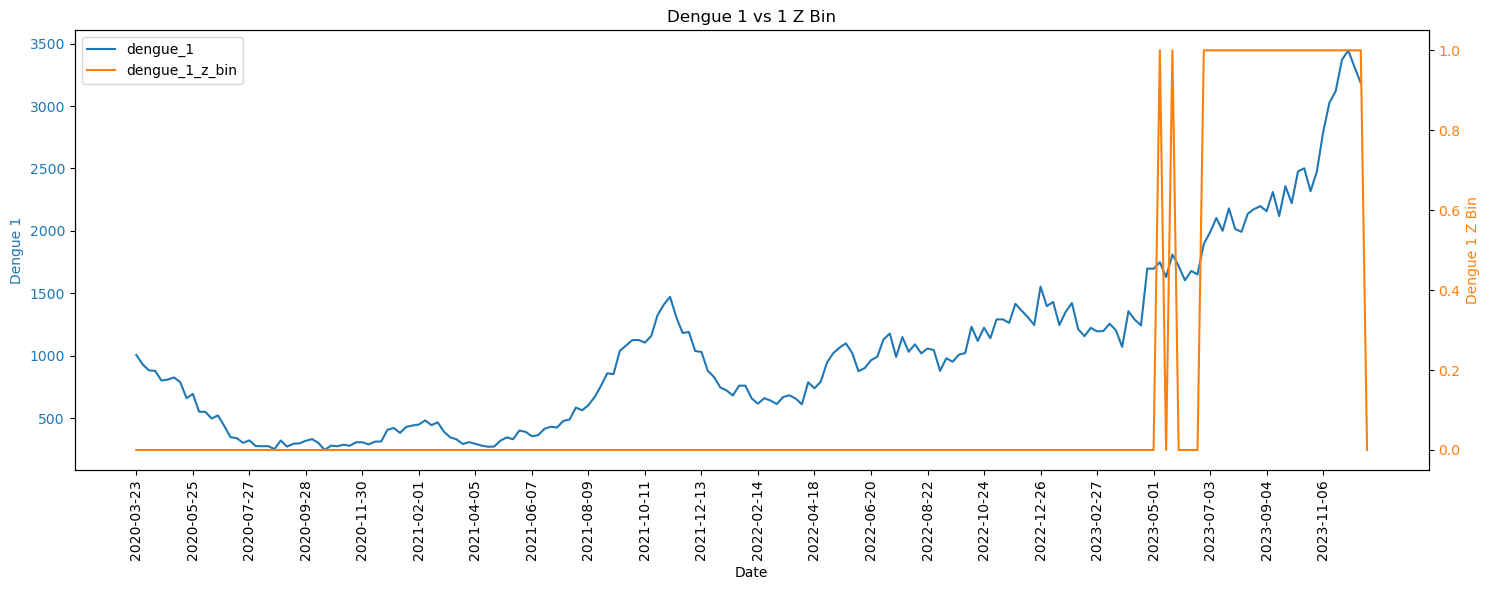

In [35]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# First axis (left)
color1 = 'tab:blue'
ax1.plot(df_final['date'], df_final['dengue_1'], color=color1, label='dengue_1')
ax1.set_xlabel('Date')
ax1.set_ylabel('Dengue 1', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Second axis (right)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.plot(df_final['date'], df_final['dengue_1_z_bin'], color=color2, label='dengue_1_z_bin')
ax2.set_ylabel('Dengue 1 Z Bin', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)


# Rotate x-axis labels for readability
ax1.set_xticks(df_final['date'][::max(len(df_final)//20, 1)])  # limit number of ticks for clarity
ax1.set_xticklabels(df_final['date'][::max(len(df_final)//20, 1)], rotation=90)

# Title and legends
plt.title('Dengue 1 vs 1 Z Bin')
fig.tight_layout()

# Add combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

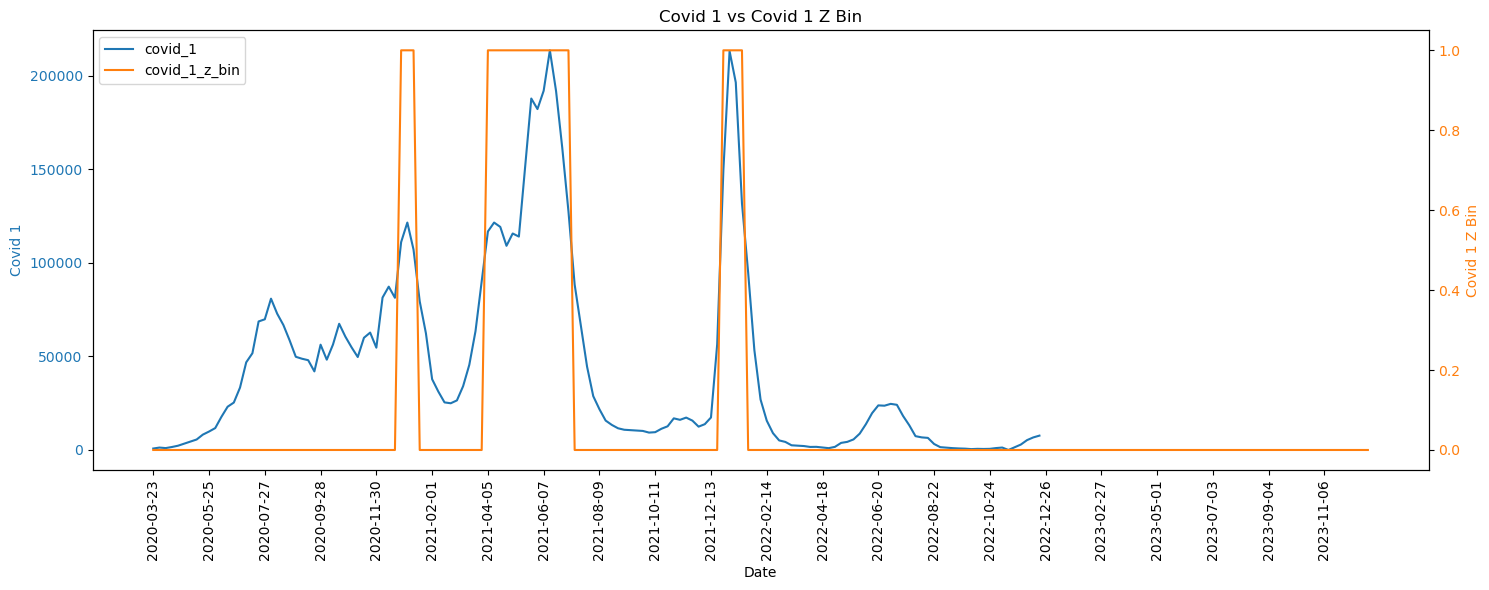

In [33]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# First axis (left)
color1 = 'tab:blue'
ax1.plot(df_final['date'], df_final['covid_1'], color=color1, label='covid_1')
ax1.set_xlabel('Date')
ax1.set_ylabel('Covid 1', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Second axis (right)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.plot(df_final['date'], df_final['covid_1_z_bin'], color=color2, label='covid_1_z_bin')
ax2.set_ylabel('Covid 1 Z Bin', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)


# Rotate x-axis labels for readability
ax1.set_xticks(df_final['date'][::max(len(df_final)//20, 1)])  # limit number of ticks for clarity
ax1.set_xticklabels(df_final['date'][::max(len(df_final)//20, 1)], rotation=90)


# Title and legends
plt.title('Covid 1 vs Covid 1 Z Bin')
fig.tight_layout()

# Add combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

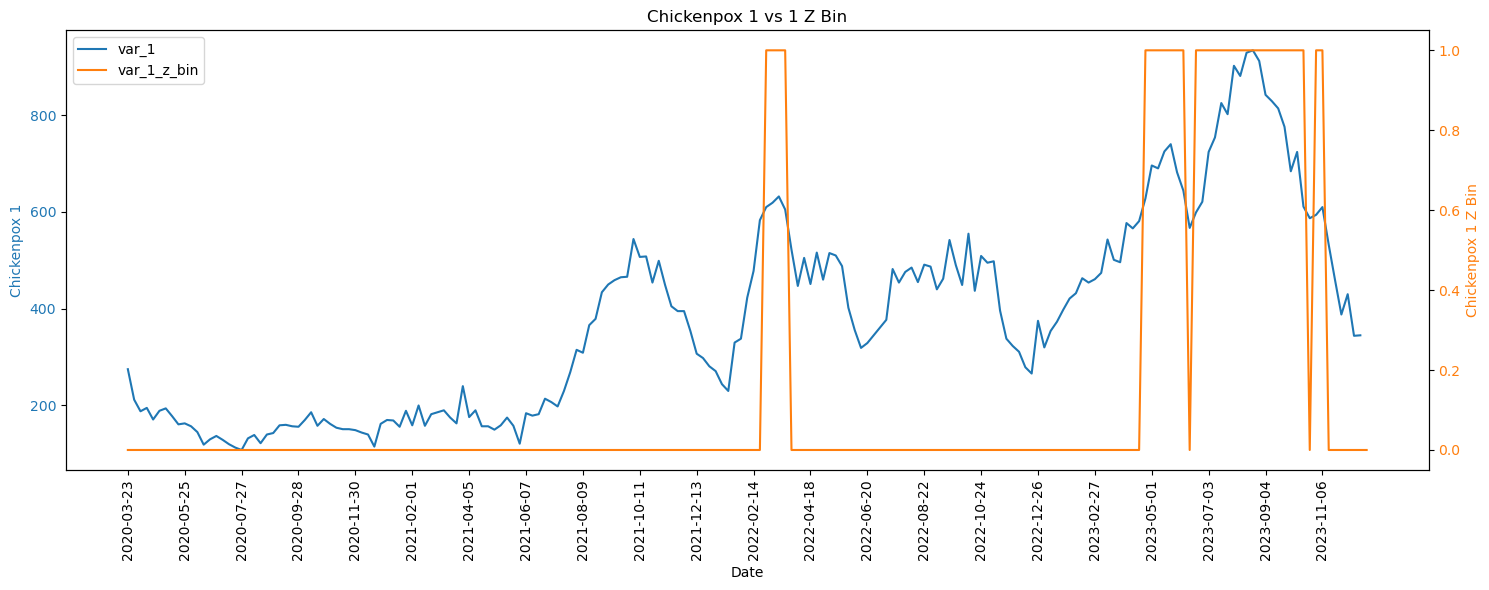

In [34]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# First axis (left)
color1 = 'tab:blue'
ax1.plot(df_final['date'], df_final['var_1'], color=color1, label='var_1')
ax1.set_xlabel('Date')
ax1.set_ylabel('Chickenpox 1', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Second axis (right)
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.plot(df_final['date'], df_final['var_1_z_bin'], color=color2, label='var_1_z_bin')
ax2.set_ylabel('Chickenpox 1 Z Bin', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)


# Rotate x-axis labels for readability
ax1.set_xticks(df_final['date'][::max(len(df_final)//20, 1)])  # limit number of ticks for clarity
ax1.set_xticklabels(df_final['date'][::max(len(df_final)//20, 1)], rotation=90)

# Title and legends
plt.title('Chickenpox 1 vs 1 Z Bin')
fig.tight_layout()

# Add combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

# Models

In [36]:
binary_targets = ['dengue_1_z_bin', 'var_1_z_bin', 'covid_1_z_bin']


In [55]:
# import logit
import statsmodels.api as sm
# logit for dengue_1_z_bin

y = df_final['dengue_1_z_bin']
X = df_final[['tavg', 'prcp', 'wspd',  'mob_index', 'google_physician',
       'google_hospital',  'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2']]
X = X.dropna()
X = sm.add_constant(X)
y = y.dropna()

In [54]:
print(len(X))
print(len(y))

197
197


In [56]:
# do the logit
logit_model = sm.Logit(y, X)
result = logit_model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.062493
         Iterations 13


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         dengue_1_z_bin   No. Observations:                  197
Model:                          Logit   Df Residuals:                      181
Method:                           MLE   Df Model:                           15
Date:                Mon, 07 Apr 2025   Pseudo R-squ.:                  0.8471
Time:                        10:46:03   Log-Likelihood:                -12.311
converged:                       True   LL-Null:                       -80.537
Covariance Type:            nonrobust   LLR p-value:                 1.152e-21
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               84.5746     74.824      1.130      0.258     -62.077     231.226
tavg                -1.6908      3.225     -0.524      0.600      -8.011       4.629
prcp                -0.3785      0.573     -0.660      0.509      -1.502       0.745
wspd                 0.9811      1.719      0.571      0.568      -2.389       4.351
mob_index            0.0041      0.139      0.030      0.976      -0.268       0.276
google_physician    -0.1230      0.259     -0.475      0.635      -0.631       0.385
google_hospital      1.0332      0.496      2.084      0.037       0.061       2.005
google_symptom      -2.6277      1.143     -2.298      0.022      -4.869      -0.387
co                   0.3617      0.578      0.625      0.532      -0.772       1.495
dew                  5.2201      2.873      1.817      0.069      -0.410      10.850
humidity            -0.8864      0.506     -1.751      0.080      -1.879       0.106
no2                 -0.1347      0.602     -0.224      0.823      -1.315       1.045
o3                   0.4201      0.667      0.630      0.529      -0.888       1.728
pm10                -0.0486      0.409     -0.119      0.905      -0.851       0.753
pm25                -0.0881      0.294     -0.299      0.765      -0.665       0.489
so2                  1.7999      7.898      0.228      0.820     -13.680      17.280
====================================================================================

Possibly complete quasi-separation: A fraction 0.69 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

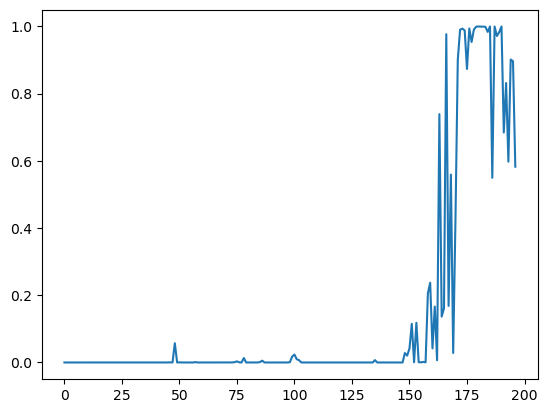

In [58]:
# get the probabilities of the model
y_pred = result.predict(X)
y_pred = pd.Series(y_pred, index=X.index)
plt.plot(y_pred)